Pehle problem samjho

Maan lo tum ghar ki electricity bill predict karna chahte ho.

Tumhare paas ye features hain:

Ghar ka size

Kitne log rehte hain

AC hai ya nahi

Car hai ya nahi

Dog hai ya nahi

Garden hai ya nahi

Ab ho sakta hai ki Dog ya Garden ka electricity bill se koi relation hi na ho.

Lekin normal Linear Regression har feature ko importance de deta hai.

Example:

Bill = 5×Size
     + 2×People
     + 0.8×AC
     + 0.1×Dog
     + 0.05×Garden

Yahan Dog aur Garden bas faltu hain.

# Lasso Regression kya karta hai?

Lasso bolta hai:

"Jo feature kaam ka nahi hai, use model se hi hata do."

Matlab us feature ka coefficient 0 kar deta hai.

Example:

Before Lasso

Bill = 5×Size
     +2×People
     +0.8×AC
     +0.1×Dog
     +0.05×Garden

After Lasso

Bill = 5×Size
     +2×People
     +0.8×AC
     +0×Dog
     +0×Garden

Ab model sirf important cheezon ko use karega.

# Ye karta kaise hai?

Loss function me ek extra punishment add karta hai.

Normal Linear Regression

Loss = Error

Lasso Regression

Loss = Error + λ × (|w1| + |w2| + |w3| + ...)

Yahan:

Error → prediction kitni galat hai.

λ (Lambda) → punishment kitni deni hai.

|w| → coefficient ki absolute value.

Jitna bada coefficient hoga, utni zyada penalty milegi.

# Isse kya hota hai?

Model sochta hai:

"Agar Dog se prediction me kuch khaas farq nahi aa raha, to iska coefficient 0 hi kar deta hoon."

Isi wajah se useless features remove ho jaate hain.

# Lasso ko "Feature Selection" kyu bolte hain?

Kyuki ye automatically decide karta hai:

Ye feature useful hai ✅

Ye feature useless hai ❌

Aur useless feature ka coefficient 0 kar deta hai.

# Linear Regression: Sab features ko use karta hai.
# Ridge Regression: Sab features ko rakhta hai, bas unke coefficients chhote kar deta hai.
# Lasso Regression: Useless features ke coefficients ko 0 kar deta hai, isliye model sirf important features ko use karta hai.

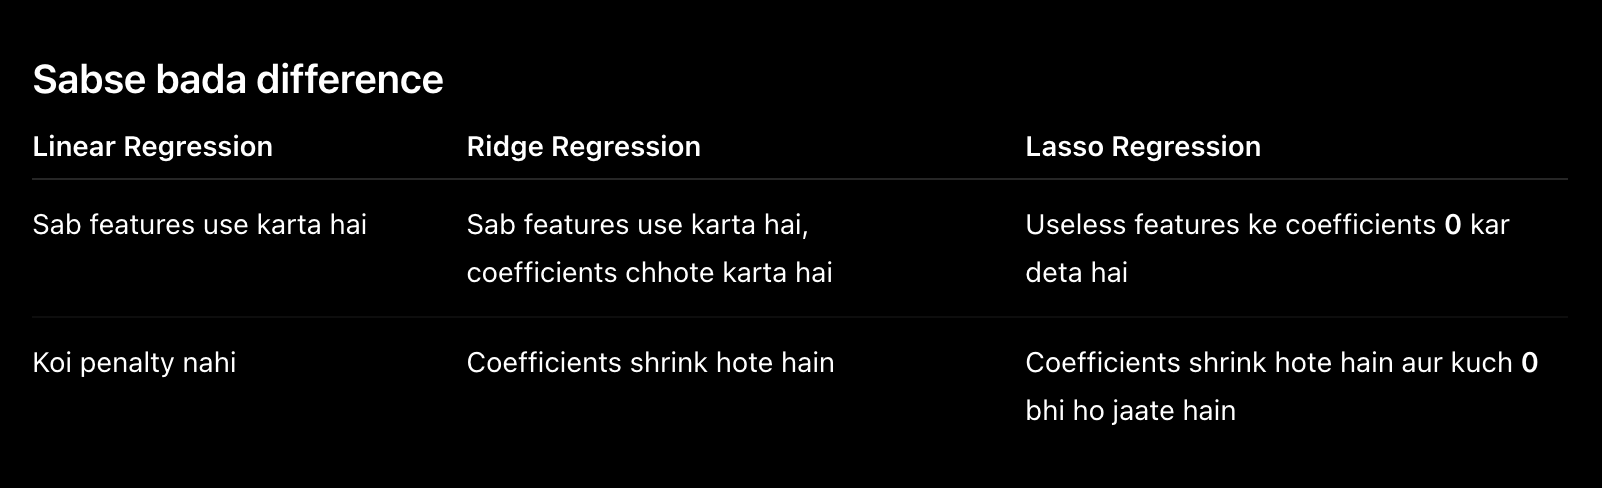

# Ridge regression exmaple

Maan lo hume exam ke marks predict karne hain.

Features:

Study Hours ✅

Attendance ✅

Sleep ✅

Shoe Color ❌

Hair Length ❌

Normal Linear Regression

Marks =
8×Study
+3×Attendance
+2×Sleep
+0.4×ShoeColor
+0.2×HairLength

Yahan model sab features ko use kar raha hai.

Ab Ridge Regression lagate hain

# Ridge bolta hai:

"Kisi bhi feature ko hataunga nahi, bas agar uski importance kam hai to uska coefficient aur chhota kar dunga."

To result kuch aisa ho sakta hai:

Marks =
6.8×Study
+2.6×Attendance
+1.7×Sleep
+0.08×ShoeColor
+0.03×HairLength

Dhyan do:

Study ka coefficient 8 → 6.8 ho gaya.

Attendance 3 → 2.6 ho gaya.

Sleep 2 → 1.7 ho gaya.

Shoe Color 0.4 → 0.08 ho gaya.

Hair Length 0.2 → 0.03 ho gaya.

👉 Lekin koi bhi coefficient 0 nahi hua.

# Pehle "L" ka matlab

L ka matlab hai Norm (yaani coefficients ka size measure karna).

Maan lo coefficients hain:

w = [3, -4]

Ab inka size alag-alag tareeke se measure kar sakte hain.

# L1 Norm (Lasso)

L1 me hum absolute values ka sum lete hain.

|3| + |-4|
= 3 + 4
= 7

Formula:

L1 = |w1| + |w2| + |w3| + ...

Isliye Lasso ki penalty hoti hai:

Loss = Error + λ × L1

Matlab

Loss = Error + λ(|w1| + |w2| + ...)

Isliye naam pada

L1 Norm use karta hai → L1 Regularization → Lasso Regression

# L2 Norm (Ridge)

Ab wahi coefficients lo:

w = [3, -4]

Pehle square karo.

3² = 9

(-4)² = 16

Ab add karo.

9 + 16 = 25

(Aksar mathematical definition me iska square root bhi hota hai, lekin Ridge Regression me penalty ke liye squares ka sum use kiya jata hai.)

Formula:

L2 = w1² + w2² + w3² + ...

Isliye Ridge ki penalty hoti hai:

Loss = Error + λ(w1² + w2² + ...)

Isliye naam pada

L2 Norm use karta hai → L2 Regularization → Ridge Regression

# Lasso ko L1 isliye kehte hain kyunki uski penalty coefficients ke absolute values (L1 norm) ka sum hoti hai. Ridge ko L2 isliye kehte hain kyunki uski penalty coefficients ke squares (L2 norm) ka sum hoti hai. Isi mathematical difference ki wajah se Lasso coefficients ko 0 kar sakta hai, jabki Ridge unhe sirf shrink karta hai.

# Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[27.8816114]
-1.8361658013524413


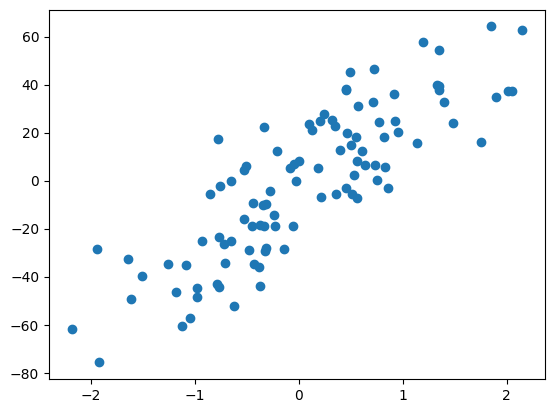

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.113e+04, tolerance: 7.085e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

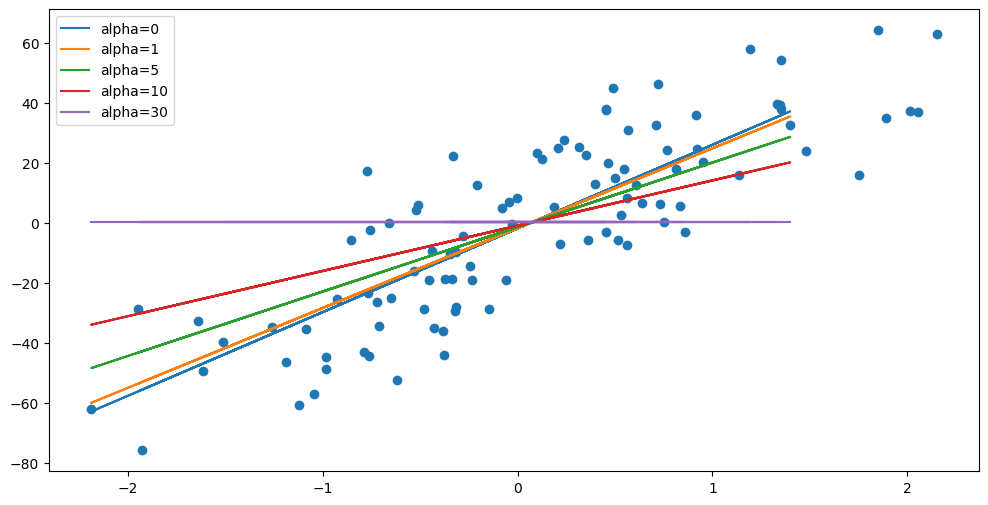

In [3]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.show()

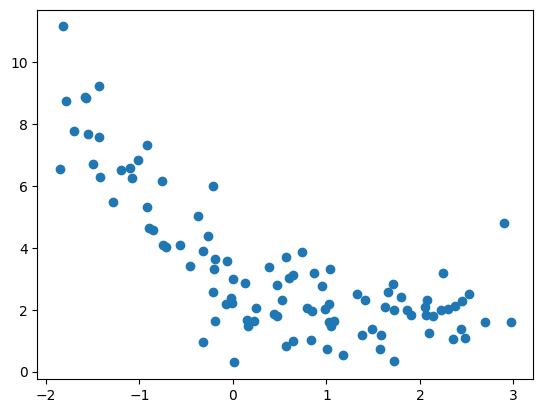

In [4]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.947e+01, tolerance: 5.317e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

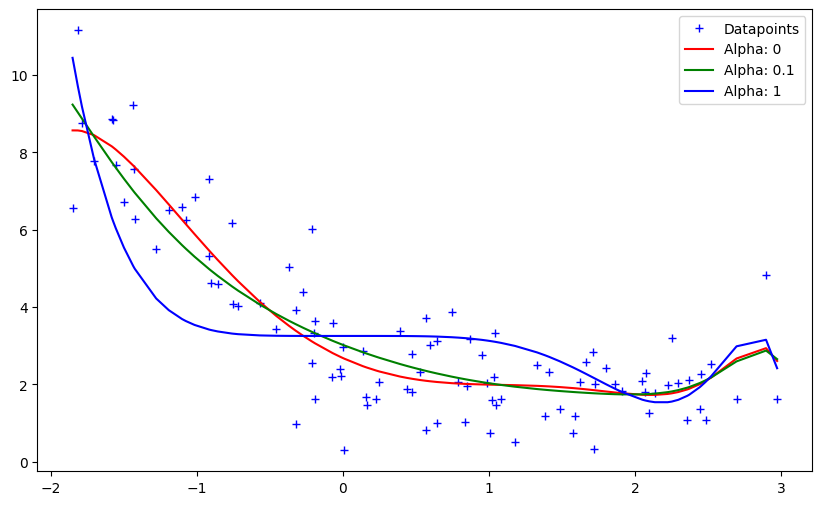

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

# 1. How are coefficients affected?

In [6]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

from sklearn.model_selection import train_test_split

In [7]:
data = load_diabetes()

df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [9]:
coefs = []
r2_scores = []

for i in [0,0.1,1,10]:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

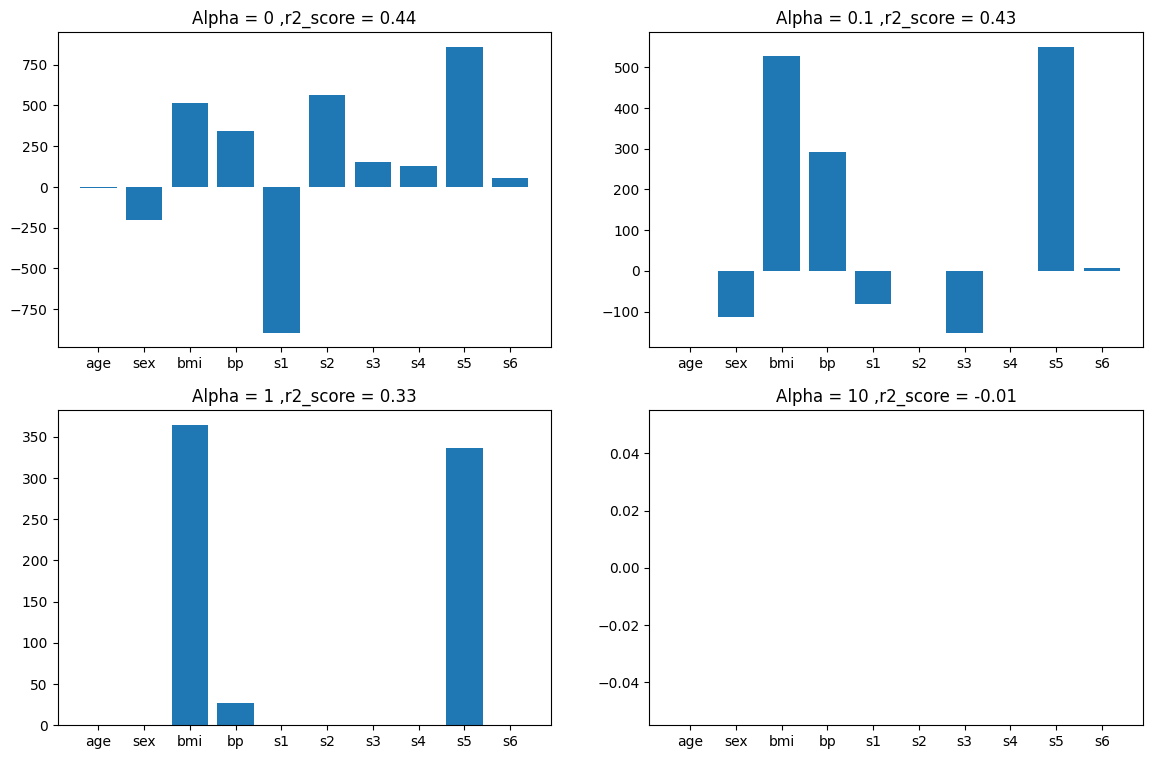

In [10]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 0.1 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 1 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()

# 2. Higher Coefficients are affected more

In [11]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

In [12]:
input_array = np.array(coefs)

coef_df = pd.DataFrame(input_array,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.551989,561.220669,153.893104,126.731395,861.126997,52.421122
0.0001,-9.069064,-205.329406,516.789418,340.532379,-888.660904,555.958584,150.593655,125.450143,858.645541,52.380294
0.0010,-8.262770,-204.205364,517.650073,339.743901,-826.663603,508.617395,120.908607,113.921773,836.320753,52.012849
0.0100,-1.359721,-192.937180,526.356514,332.641101,-430.226975,191.295480,-44.034913,68.988987,688.396028,47.940616
0.1000,0.000000,-113.969928,526.744396,292.628472,-82.693681,-0.000000,-152.685338,0.000000,551.080291,7.170992
1.0000,0.000000,0.000000,363.885742,27.273163,0.000000,0.000000,-0.000000,0.000000,336.137262,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
100.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
1000.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


In [13]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

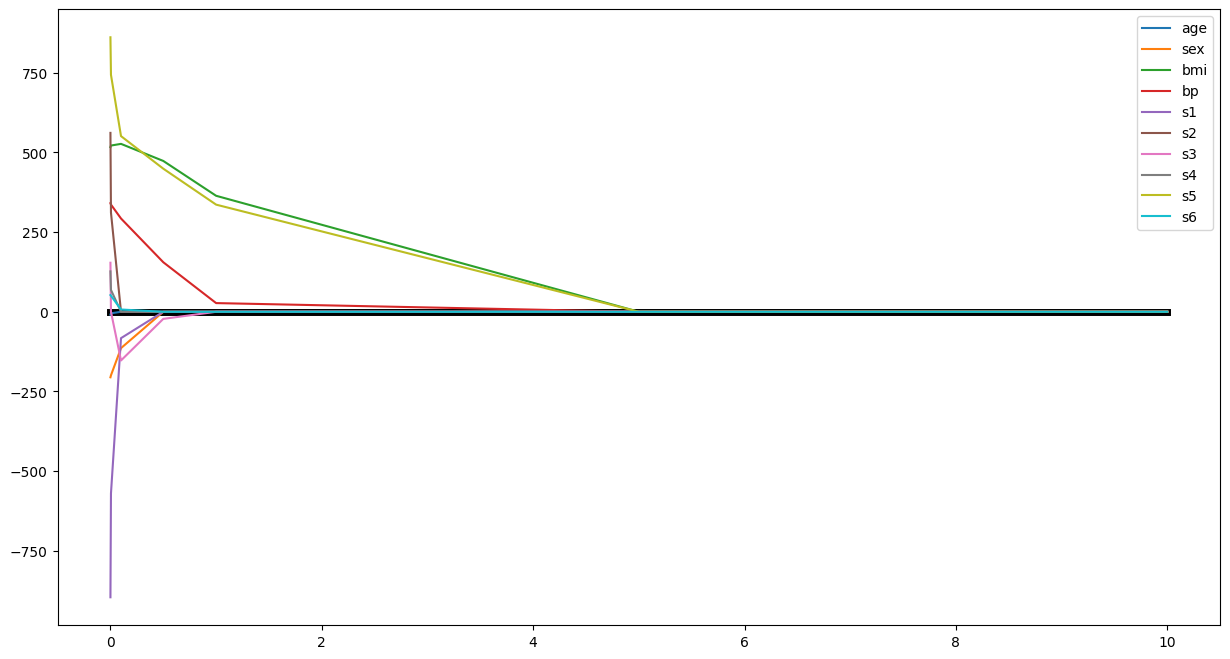

In [14]:
input_array = np.array(coefs).T

plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()

# 3. Impact on Bias and Variance

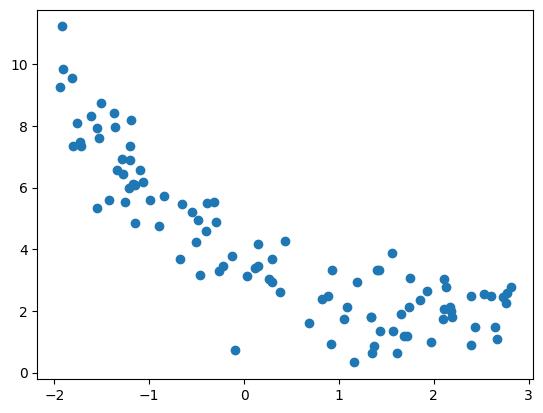

In [15]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()


In [16]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)

In [17]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=10)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [18]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Lasso(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test,
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.124e+00, tolerance: 5.233e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.011e+00, tolerance: 4.197e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

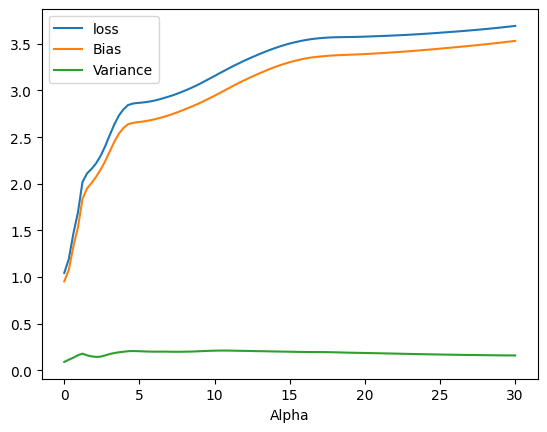

In [19]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.xlabel('Alpha')
plt.legend()


# 4. Effect of Regularization on Loss Function

[27.82809103]
-2.29474455867698


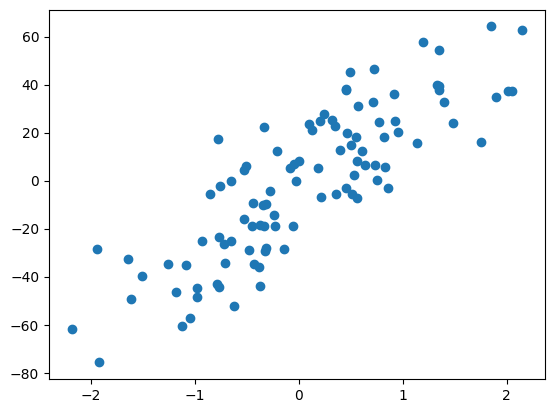

In [20]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [21]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*abs(m)


In [22]:
def predict(m):
    return m*X - 2.29

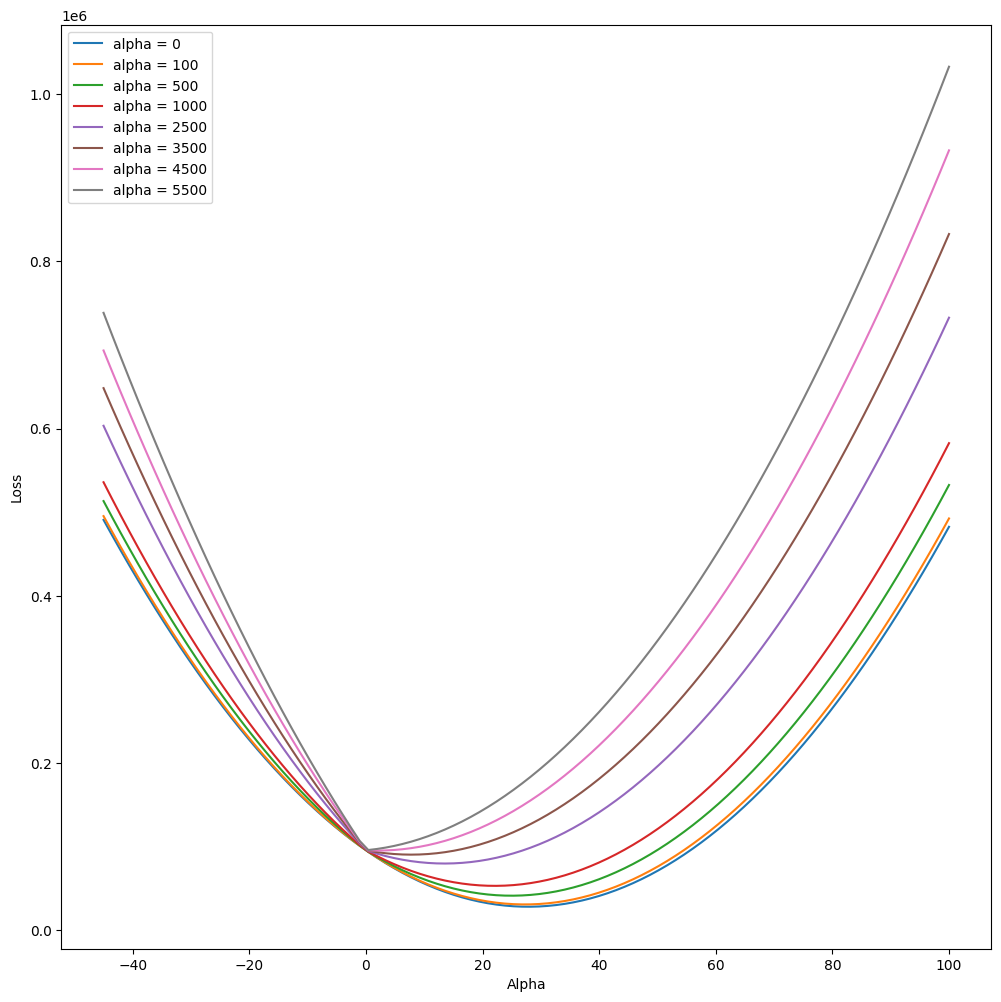

In [23]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(12,12))
for j in [0,100,500,1000,2500,3500,4500,5500]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.show()

#  How are coefficients affected with Lambda and Alpha

# Case 1: Lambda / Alpha = 0

Koi penalty nahi.

Coefficient:

Study Hours = 8

Attendance = 3

Sleep = 2

Model bilkul Linear Regression ki tarah behave karega.

# Case 2: Lambda / Alpha thoda bada

Thodi penalty lagegi.

Ridge

8 → 6.5

3 → 2.5

2 → 1.6

Sab coefficients chhote ho gaye.

Lasso

8 → 7

3 → 2.8

2 → 1.8

0.4 → 0

0.2 → 0

Chhote coefficients me se kuch 0 bhi ho gaye.

# Case 3: Lambda / Alpha bahut bada

Penalty bahut zyada.

Ridge

8 → 0.8

3 → 0.3

2 → 0.2

Sab coefficients bahut chhote ho gaye, lekin 0 nahi hue.

Lasso

8 → 0

3 → 0

2 → 0

0.4 → 0

0.2 → 0

Lagbhag sab coefficients 0 ho sakte hain.

Model bahut simple ho jayega aur prediction bhi kharab ho sakti hai (underfitting).

```
Lambda/Alpha ↓ (kam) → Coefficients bade rehte hain.
Lambda/Alpha ↑ (zyada) → Coefficients chhote hote hain.
Ridge: Coefficients shrink hote hain, 0 nahi hote.
Lasso: Kuch coefficients exactly 0 ho jaate hain, isliye feature selection hoti hai.
```

# Higher Coefficients are affected more

Pehle example lete hain

Maan lo coefficients hain:

Study Hours = 10

Attendance = 5

Sleep = 2

Shoe Color = 0.5

Ab regularization (Ridge ya Lasso) lagate hain.

Result:

Study Hours = 7

Attendance = 3.8

Sleep = 1.5

Shoe Color = 0.2

Dhyan do:

10 → 7 (3 kam hua)
5 → 3.8 (1.2 kam hua)
2 → 1.5 (0.5 kam hua)
0.5 → 0.2 (0.3 kam hua)

Bade coefficients par penalty ka effect zyada dikhai deta hai.

# Aisa kyu hota hai?

Regularization bolti hai:

"Jiska coefficient jitna bada hoga, us par utni zyada penalty lagegi."

Ridge (L2)

Penalty hoti hai:

Penalty = λ(w₁² + w₂² + ...)

Agar coefficient 10 hai:

10² = 100

Agar coefficient 2 hai:

2² = 4

👉 100 ki penalty, 4 se bahut zyada hai.

Isliye bada coefficient zyada shrink hota hai.

# Lasso (L1)

Penalty hoti hai:

Penalty = λ(|w₁| + |w₂| + ...)

Yahan bhi:

|10| = 10
|2| = 2

Bada coefficient zyada penalty contribute karta hai, isliye optimization usse bhi reduce karne ki koshish karta hai. Saath hi, chhote coefficients ko 0 kar dena bhi aasaan hota hai.

#  Impact of Lambda on Bias and Variance

Pehle Bias aur Variance samjho

 # Bias = Model kitna simple hai

High Bias matlab:

"Model ne data ko achhe se seekha hi nahi."

Example:

Ek teacher har student ko 70 marks hi de deta hai.

Chahe kisi ne achha likha ho ya bura.

Ye High Bias hai.

 # Variance = Model kitna over-smart hai

High Variance matlab:

"Model training data ko rat gaya."

Example:

Teacher har spelling mistake tak yaad rakh leta hai.

Exam badal gaya to fail.

Ye High Variance hai.

# Ab Lambda ka effect
1. Lambda bahut chhota (λ ≈ 0)

Penalty lagbhag nahi hai.

Model:

Sab coefficients use karega.

Bahut complex ban jayega.

Training data ko yaad kar lega.

Result:

Bias ↓ (Low)

Variance ↑ (High)

Example:

Ek student har question rat leta hai.

New question aaya to confuse.

 # 2. Lambda Medium

Thodi penalty.

Model unnecessary complexity hata deta hai.

Result:

Bias = Medium

Variance = Medium

Ye best situation hoti hai.

# 3. Lambda Bahut Bada

Penalty bahut zyada.

Model bolta hai:

"Main zyada kuch seekhunga hi nahi."

Coefficients bahut chhote ho jate hain.

Result:

Bias ↑ (High)

Variance ↓ (Low)

Example:

Teacher har student ko same answer likhne bolta hai.

Ab galti kam hogi, lekin accuracy bhi kam hogi.

# Effect of Regularization on Loss Function

Pehle Loss Function kya hota hai?

Loss Function batata hai:

Model kitni galti (Error) kar raha hai.

Agar prediction galat hai:

Loss ↑ (High)

Agar prediction sahi hai:

Loss ↓ (Low)

Normal Linear Regression me:

Loss = Prediction Error

Model ka sirf ek goal hota hai:

"Error ko jitna ho sake kam karo."

# Problem kya thi?

Sirf Error kam karte-karte model kabhi-kabhi bahut complex ho jata hai.

Example:

Coefficients

Study = 120

Attendance = 90

Sleep = 65

Ye bahut bade coefficients hain.

Training data par to perfect prediction dega,

lekin new data par fail ho sakta hai.

Isko Overfitting kehte hain.

# Regularization kya karta hai?

Regularization bolta hai:

"Sirf Error kam mat karo, bade coefficients ki bhi punishment do."

Matlab Loss Function me ek extra term add kar dete hain.

# Regularization loss function me ek penalty term add karta hai. Is penalty ki wajah se model sirf prediction error ko hi minimize nahi karta, balki bade coefficients ko bhi reduce karta hai. Isse overfitting kam hoti hai aur model better generalize karta hai.



High Bias
=
Model ne seekha hi nahi.
=
Underfitting.

High Variance
=
Model ne rat liya.
=
Overfitting.

# Why Lasso Regression creates sparsity?

Pehle Sparsity kya hota hai?

Sparse matlab:

Jahan bahut saari values 0 ho.

Example:

Normal coefficients

[8, 5, 2, 1, 3]

Yahan koi bhi 0 nahi hai.

Ye sparse nahi hai.

Lasso ke baad

[8, 5, 0, 0, 3]

Ab do coefficients 0 ho gaye.

Ye Sparse Model hai.

Isliye kehte hain

Lasso creates sparsity.

# Lekin 0 hi kyu karta hai?

Maan lo tumhare paas 5 employees hain.

```
| Employee | Kaam            |
| -------- | --------------- |
| A        | Bahut important |
| B        | Important       |
| C        | Thoda important |
| D        | Kaam ka nahi    |
| E        | Kaam ka nahi    |

Company paisa bachana chahti hai.

To kya karegi?

# Option 1

Sabki salary thodi kam kar de.

Ye Ridge hai.

# Option 2

Jo kaam ke nahi hain unko nikal de.

Ye Lasso hai.

Result

A ✔

B ✔

C ✔

D ❌

E ❌

Ab team me sirf useful log bache.

Yehi Sparsity hai.

# Lasso mathematically kya karta hai?

Lasso ka Loss Function

Loss = Error + λ(|w₁| + |w₂| + |w₃| + ...)

Ab maan lo ek coefficient hai

0.1

Aur dusra hai

8

Model sochta hai

"0.1 se prediction me kuch khaas farq nahi aa raha."

To us coefficient ko

0.1 → 0

kar deta hai.

Kyunki 0 karne se penalty bhi kam ho jati hai.

# Lasso Regression creates sparsity because it uses the L1 penalty (sum of absolute values of coefficients). During optimization, if a feature contributes very little to reducing the prediction error, Lasso finds it beneficial to make its coefficient exactly zero to reduce the penalty. As a result, many coefficients become zero, leaving only the important features. This is called a sparse model and is why Lasso performs automatic feature selection.